sns.set() = Applies Seaborn’s default theme for better-looking plots  

import warnings = imports the warnings module to handle warnings  

warnings.filterwarnings('ignore') = Suppresses warning messages in output

In [85]:
from mlxtend.plotting import plot_decision_regions
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

I am going to use the OSEMN Pipeline

- O - Obtaining our data
- S - Scrubbing / Cleaning our data
- E - Exploring / Visualizing our data will allow us to find patterns and trends
- M - Modeling our data will give us our predictive power as a wizard
- N - Interpreting our data


## Obtaining our data and cleaning it

In [86]:
df = pd.read_csv("D:/Python Projects/Diabetes Classification/diabetes.csv")
display(df.head())
display(df.info(verbose=True))
#Used display to show every expression in my cell
#Used verbose = True to forces pandas to show all columns (makes no difference in small DataFrames)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

df.describe() method generates descriptive statisticcs that summarize the central tendency, dispersion and shape of a dataset's distribution, excluding NaN values. The describe() method will ignore any categorical values unless the parameter include = "all" is passed.

Now, let's understand the statistics that are generated by the describe() method:

- count tells us the number of NoN-empty rows in a feature
- mean tells us the mean value of that feature
- std tells us the Standard Deviation Value of that feature
- min tells us the minimum value of that feature
- 25%, 50% and 75% are the percentile/quartile of each features. For example, the third quartile of the feature "pregnancies" is 6, meaning that 25% of the data is above that number and 75%, under that number. This information helps us detect Outliers.
- max tells us the maximum value of that feature.

In [87]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


We can see that, for each column, there is 768 rows. However, a value of zero does not make sense and thus indicates missing values in the following variables:

1. Glucose
2. BloodPressure
3. SkinThickness
4. Insulin
5. BMI

It's better to replace zeros with Nan (Not a number). It will be easier to count them and to replace them with suitable values!

In [88]:
df_copy = df.copy(deep=True) #Creating a deep copy so that changes of one df will never affect the other one
df_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = df_copy[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0, np.NaN)

#Showing the count of NaNs
print(df_copy.isnull().sum())

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


We are going to fill these NaN values, but the data distribution needs to be understood. We are going to create a histogram for each numerical value.

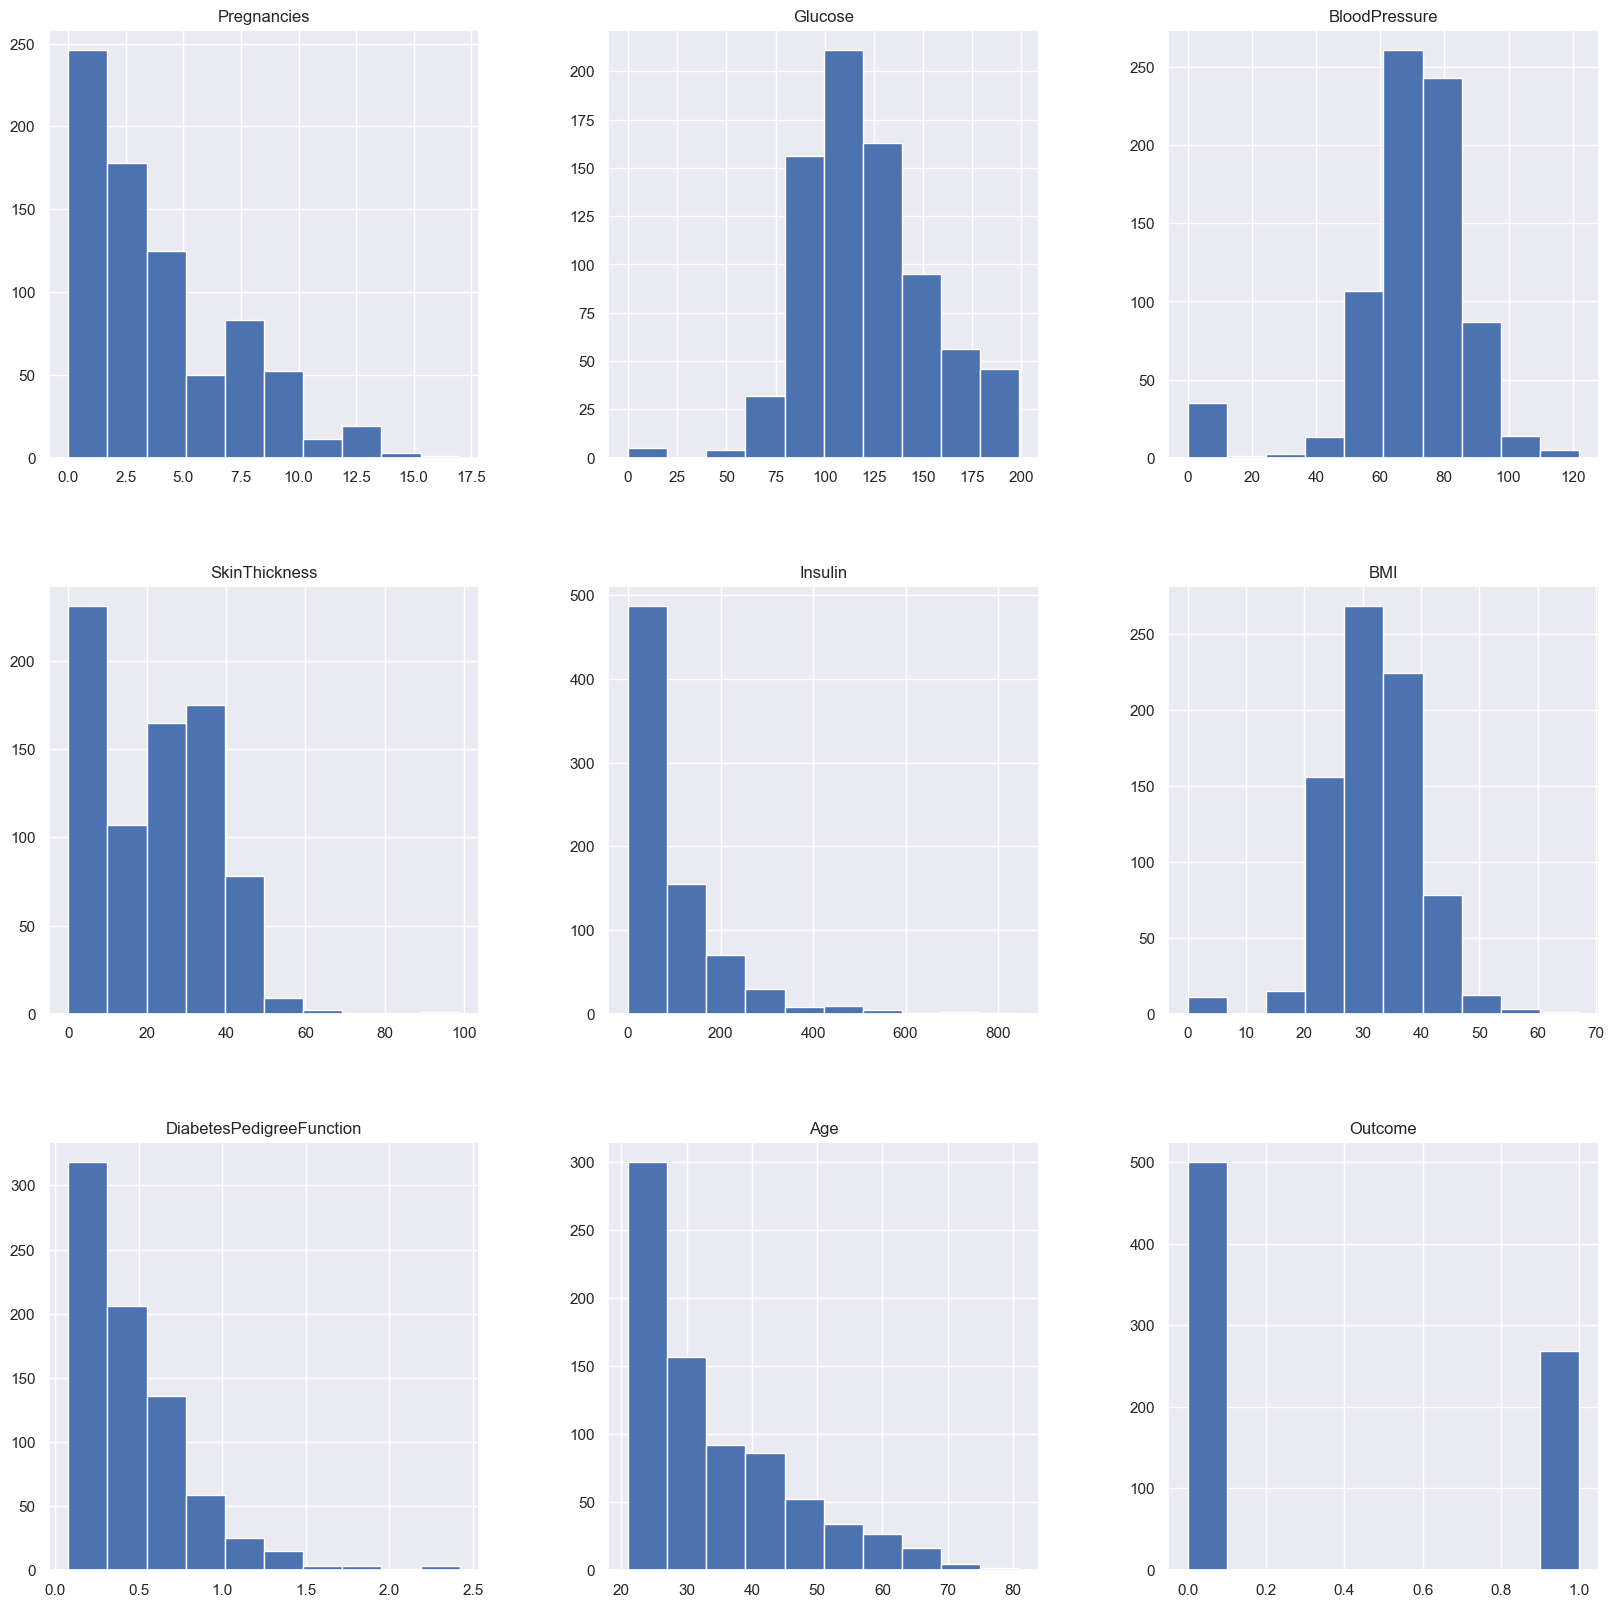

In [89]:
p= df.hist(figsize=(20,20)) #Making the figure size to 20x20 (larger and more readable)

Imputing NaN values for the columns in accordance with their distribution. 
- Use Mean: Data is normally distributed (symmetric)
- Use Median: Data has outliers or is skewed, we want a measure that is less affected by extreme values (Ex: House Prices, Salaries) - A few rich people can pull the mean way up and may not represent well the context

In [90]:
df_copy['Glucose'].fillna(df_copy['Glucose'].mean(), inplace = True) #inplace = True to modify to modify the df directly, instead of returning a new one
df_copy['BloodPressure'].fillna(df_copy['BloodPressure'].mean(), inplace = True)
df_copy['SkinThickness'].fillna(df_copy['SkinThickness'].median(), inplace = True)
df_copy['Insulin'].fillna(df_copy['Insulin'].median(), inplace = True)
df_copy['BMI'].fillna(df_copy['BMI'].mean(), inplace = True)

Plotting after NaN values removal; we now have a new df called df_copy without any NaN values.

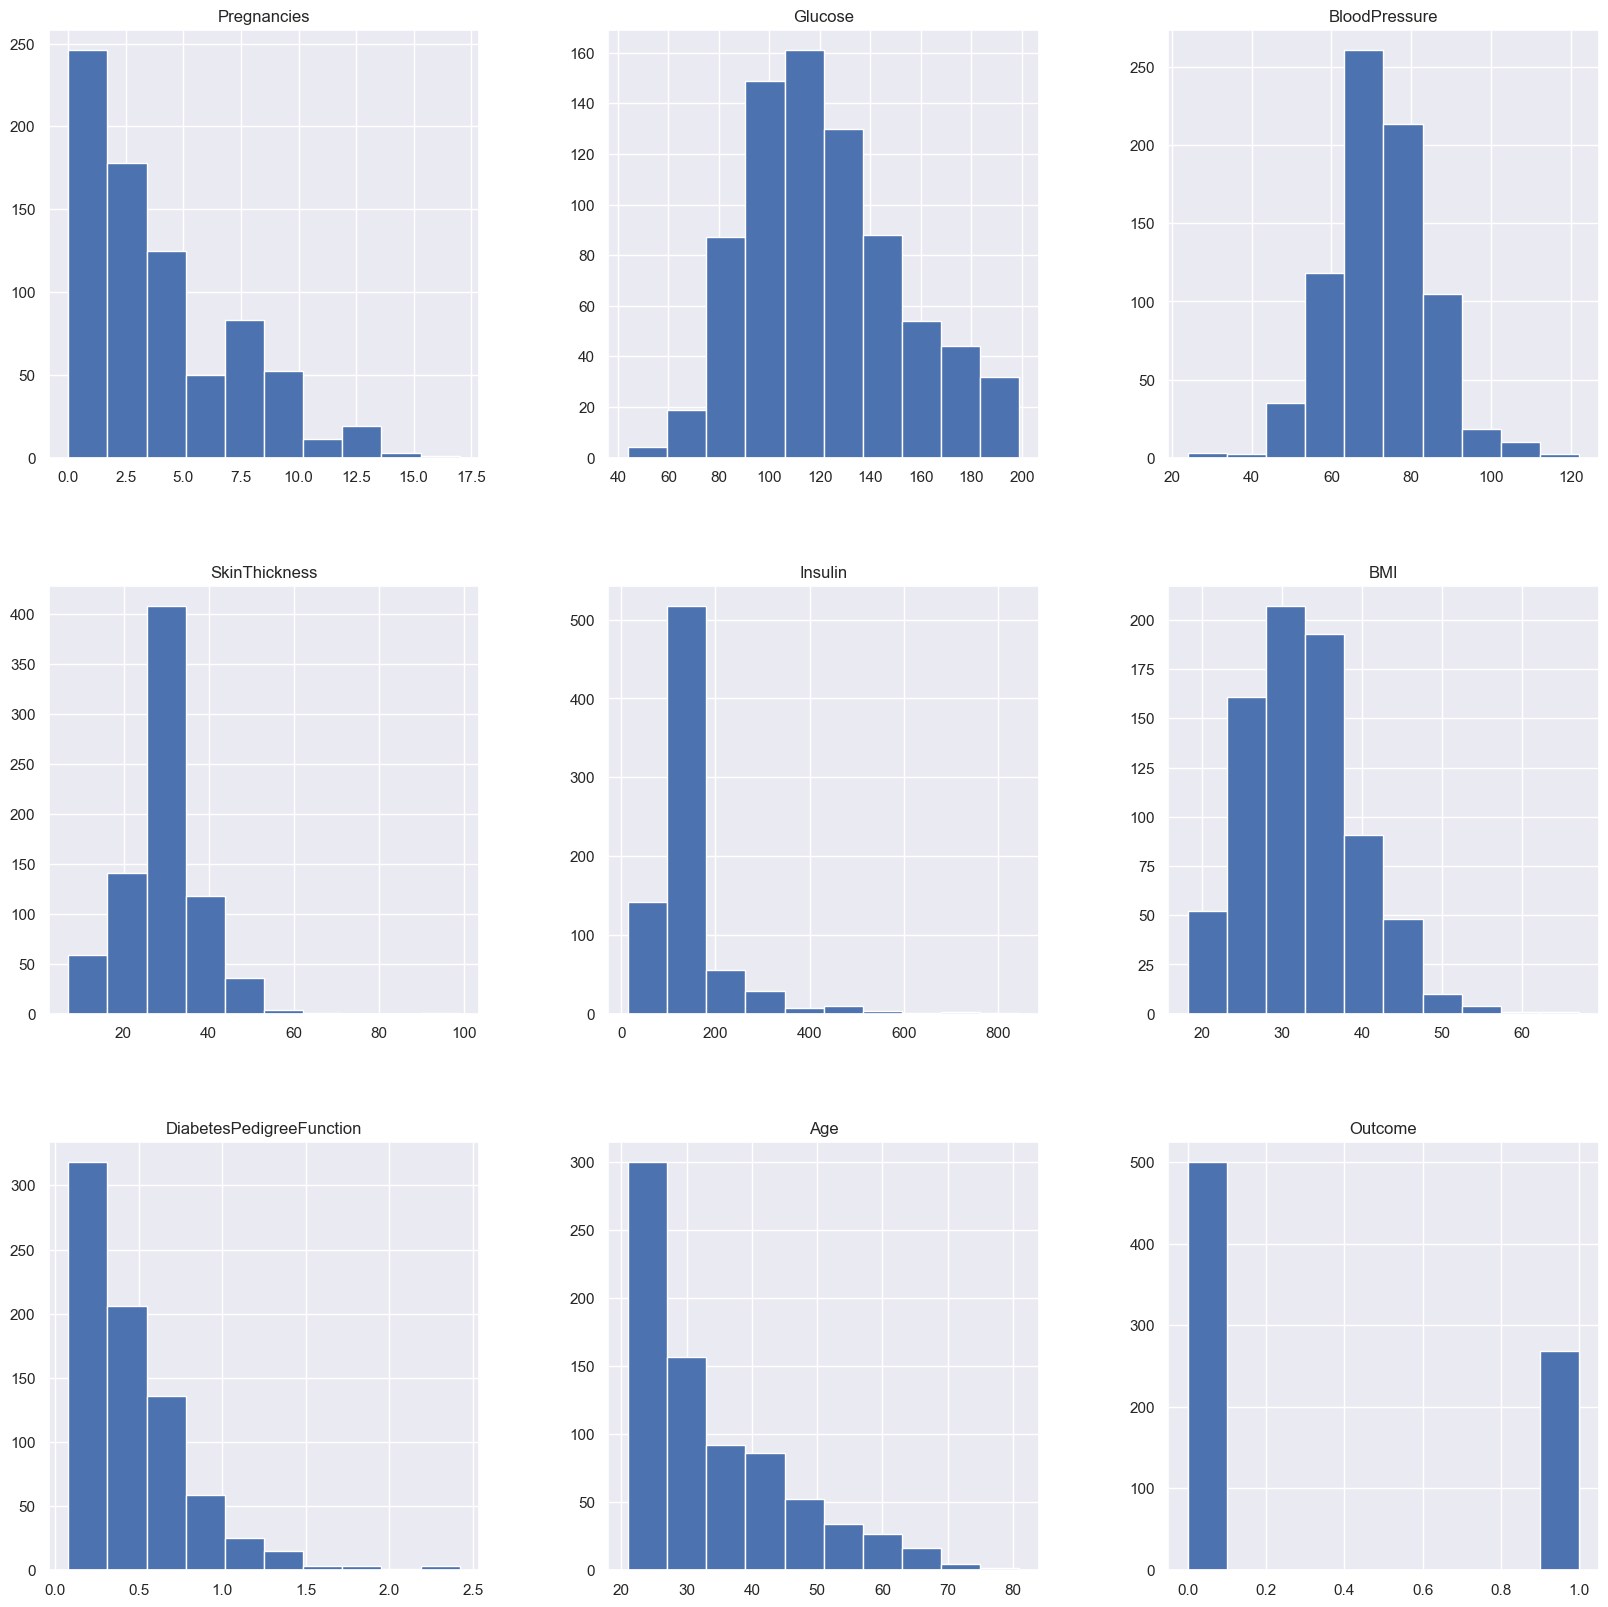

In [91]:
p = df_copy.hist(figsize=(20,20)) #We stock it in a variable p in order to avoid the display of useless information

## Exploring / Visualizing our data will allow us to find patterns and trends

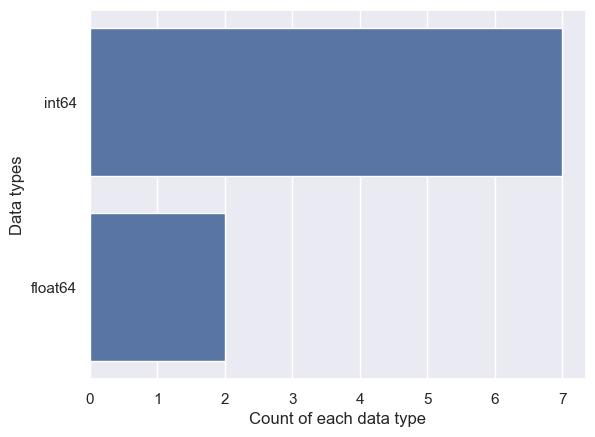

In [92]:
sns.countplot(y=df.dtypes, data=df)
plt.xlabel('Count of each data type')
plt.ylabel('Data types')
plt.show()

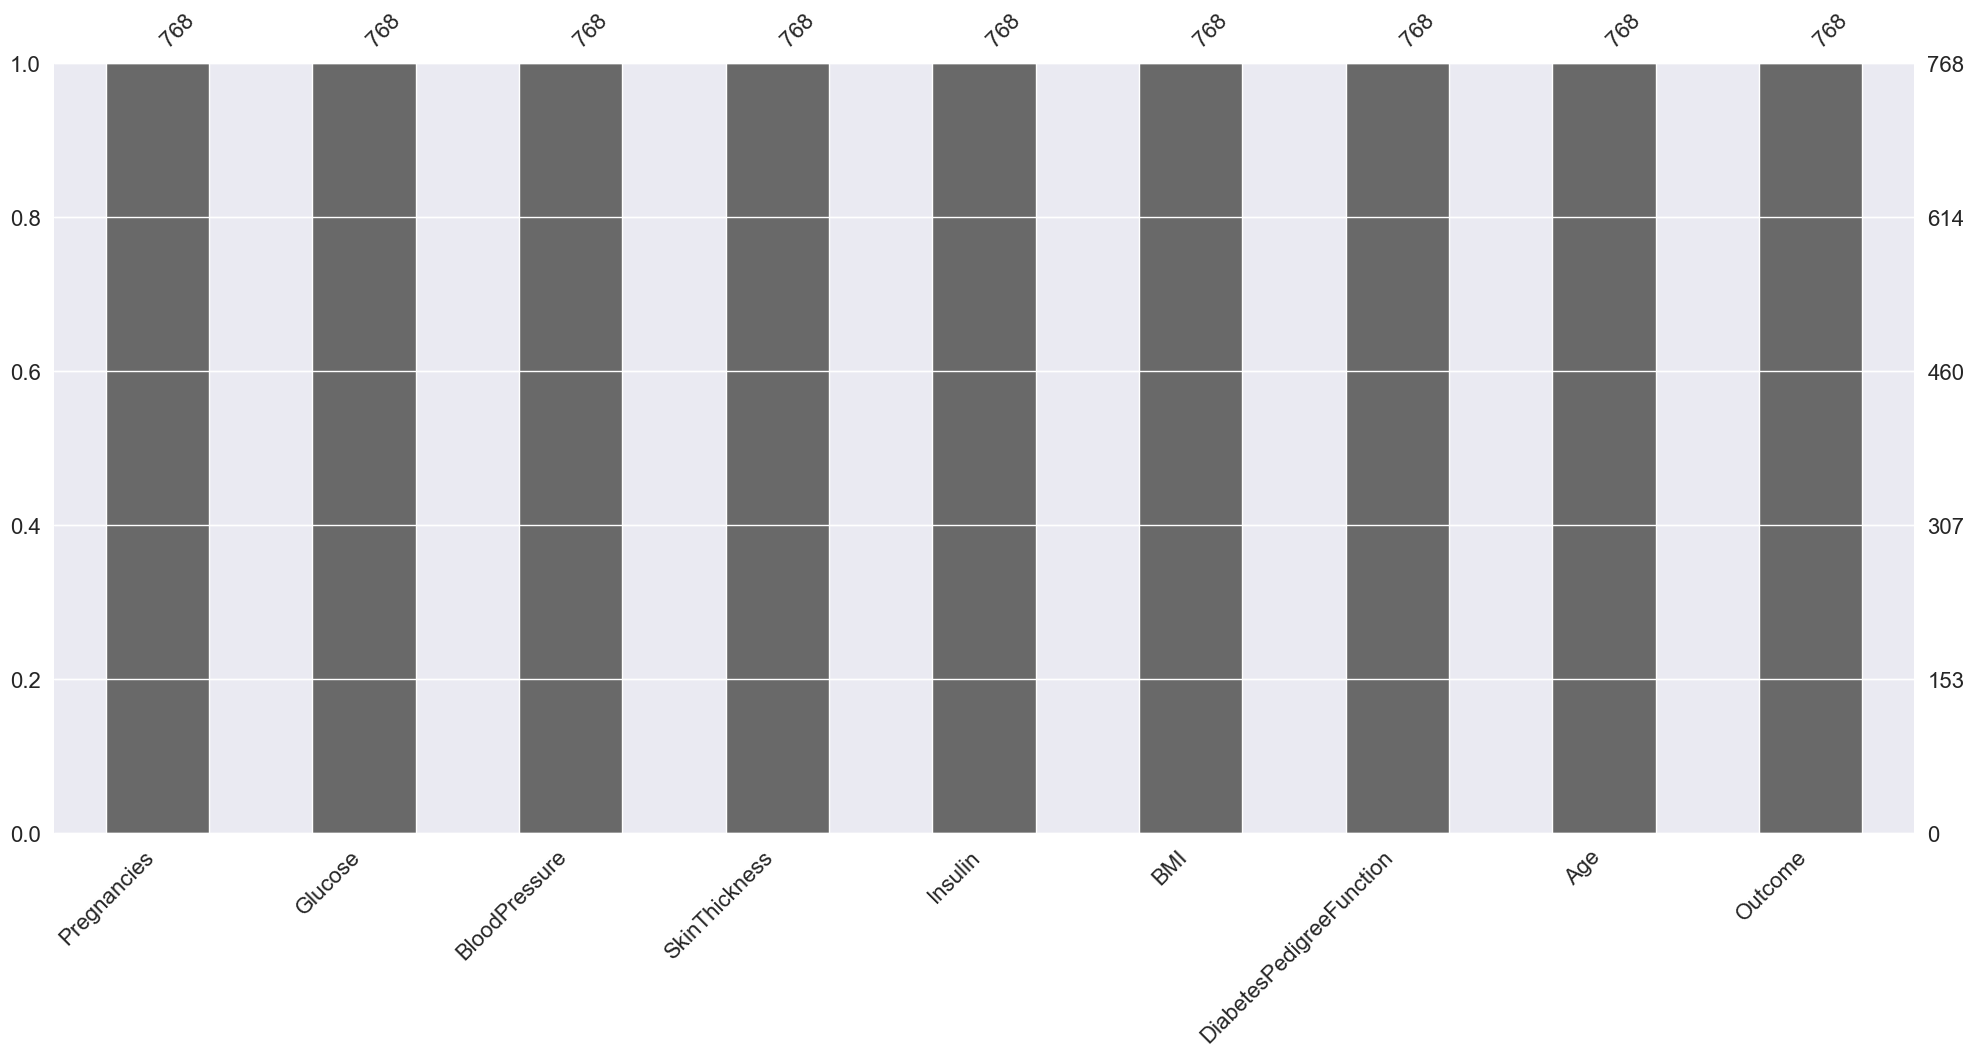

In [93]:
import missingno as msno
p = msno.bar(df) #Another way to verify if there's any missing value

Outcome
0    500
1    268
Name: count, dtype: int64


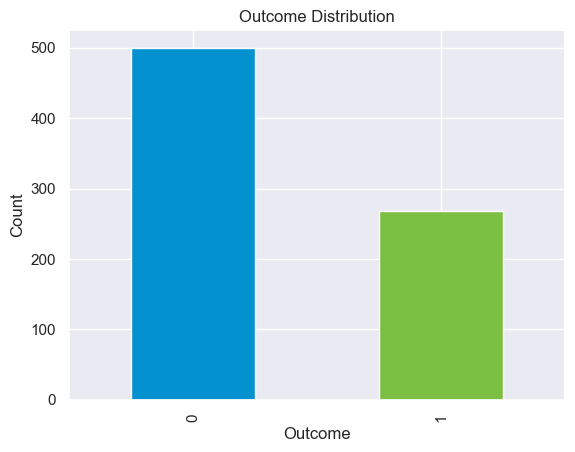

In [94]:
color_wheel = {1: "#0392cf", 2: "#7bc043"}
colors = df['Outcome'].map(lambda x: color_wheel.get((x+1),"#000000")) #Mapping Colors to Outcome Values (0 or 1)
print(df['Outcome'].value_counts())
p = df['Outcome'].value_counts().plot(kind='bar',color=[color_wheel[1],color_wheel[2]],xlabel='Outcome',ylabel='Count',title='Outcome Distribution',)


The above graph shows that the data is biased towards datapoints having outcome values as 0 where it means that diabetes was not present actually. The number of non-diabetics is almost twice the number of diabetic patients.

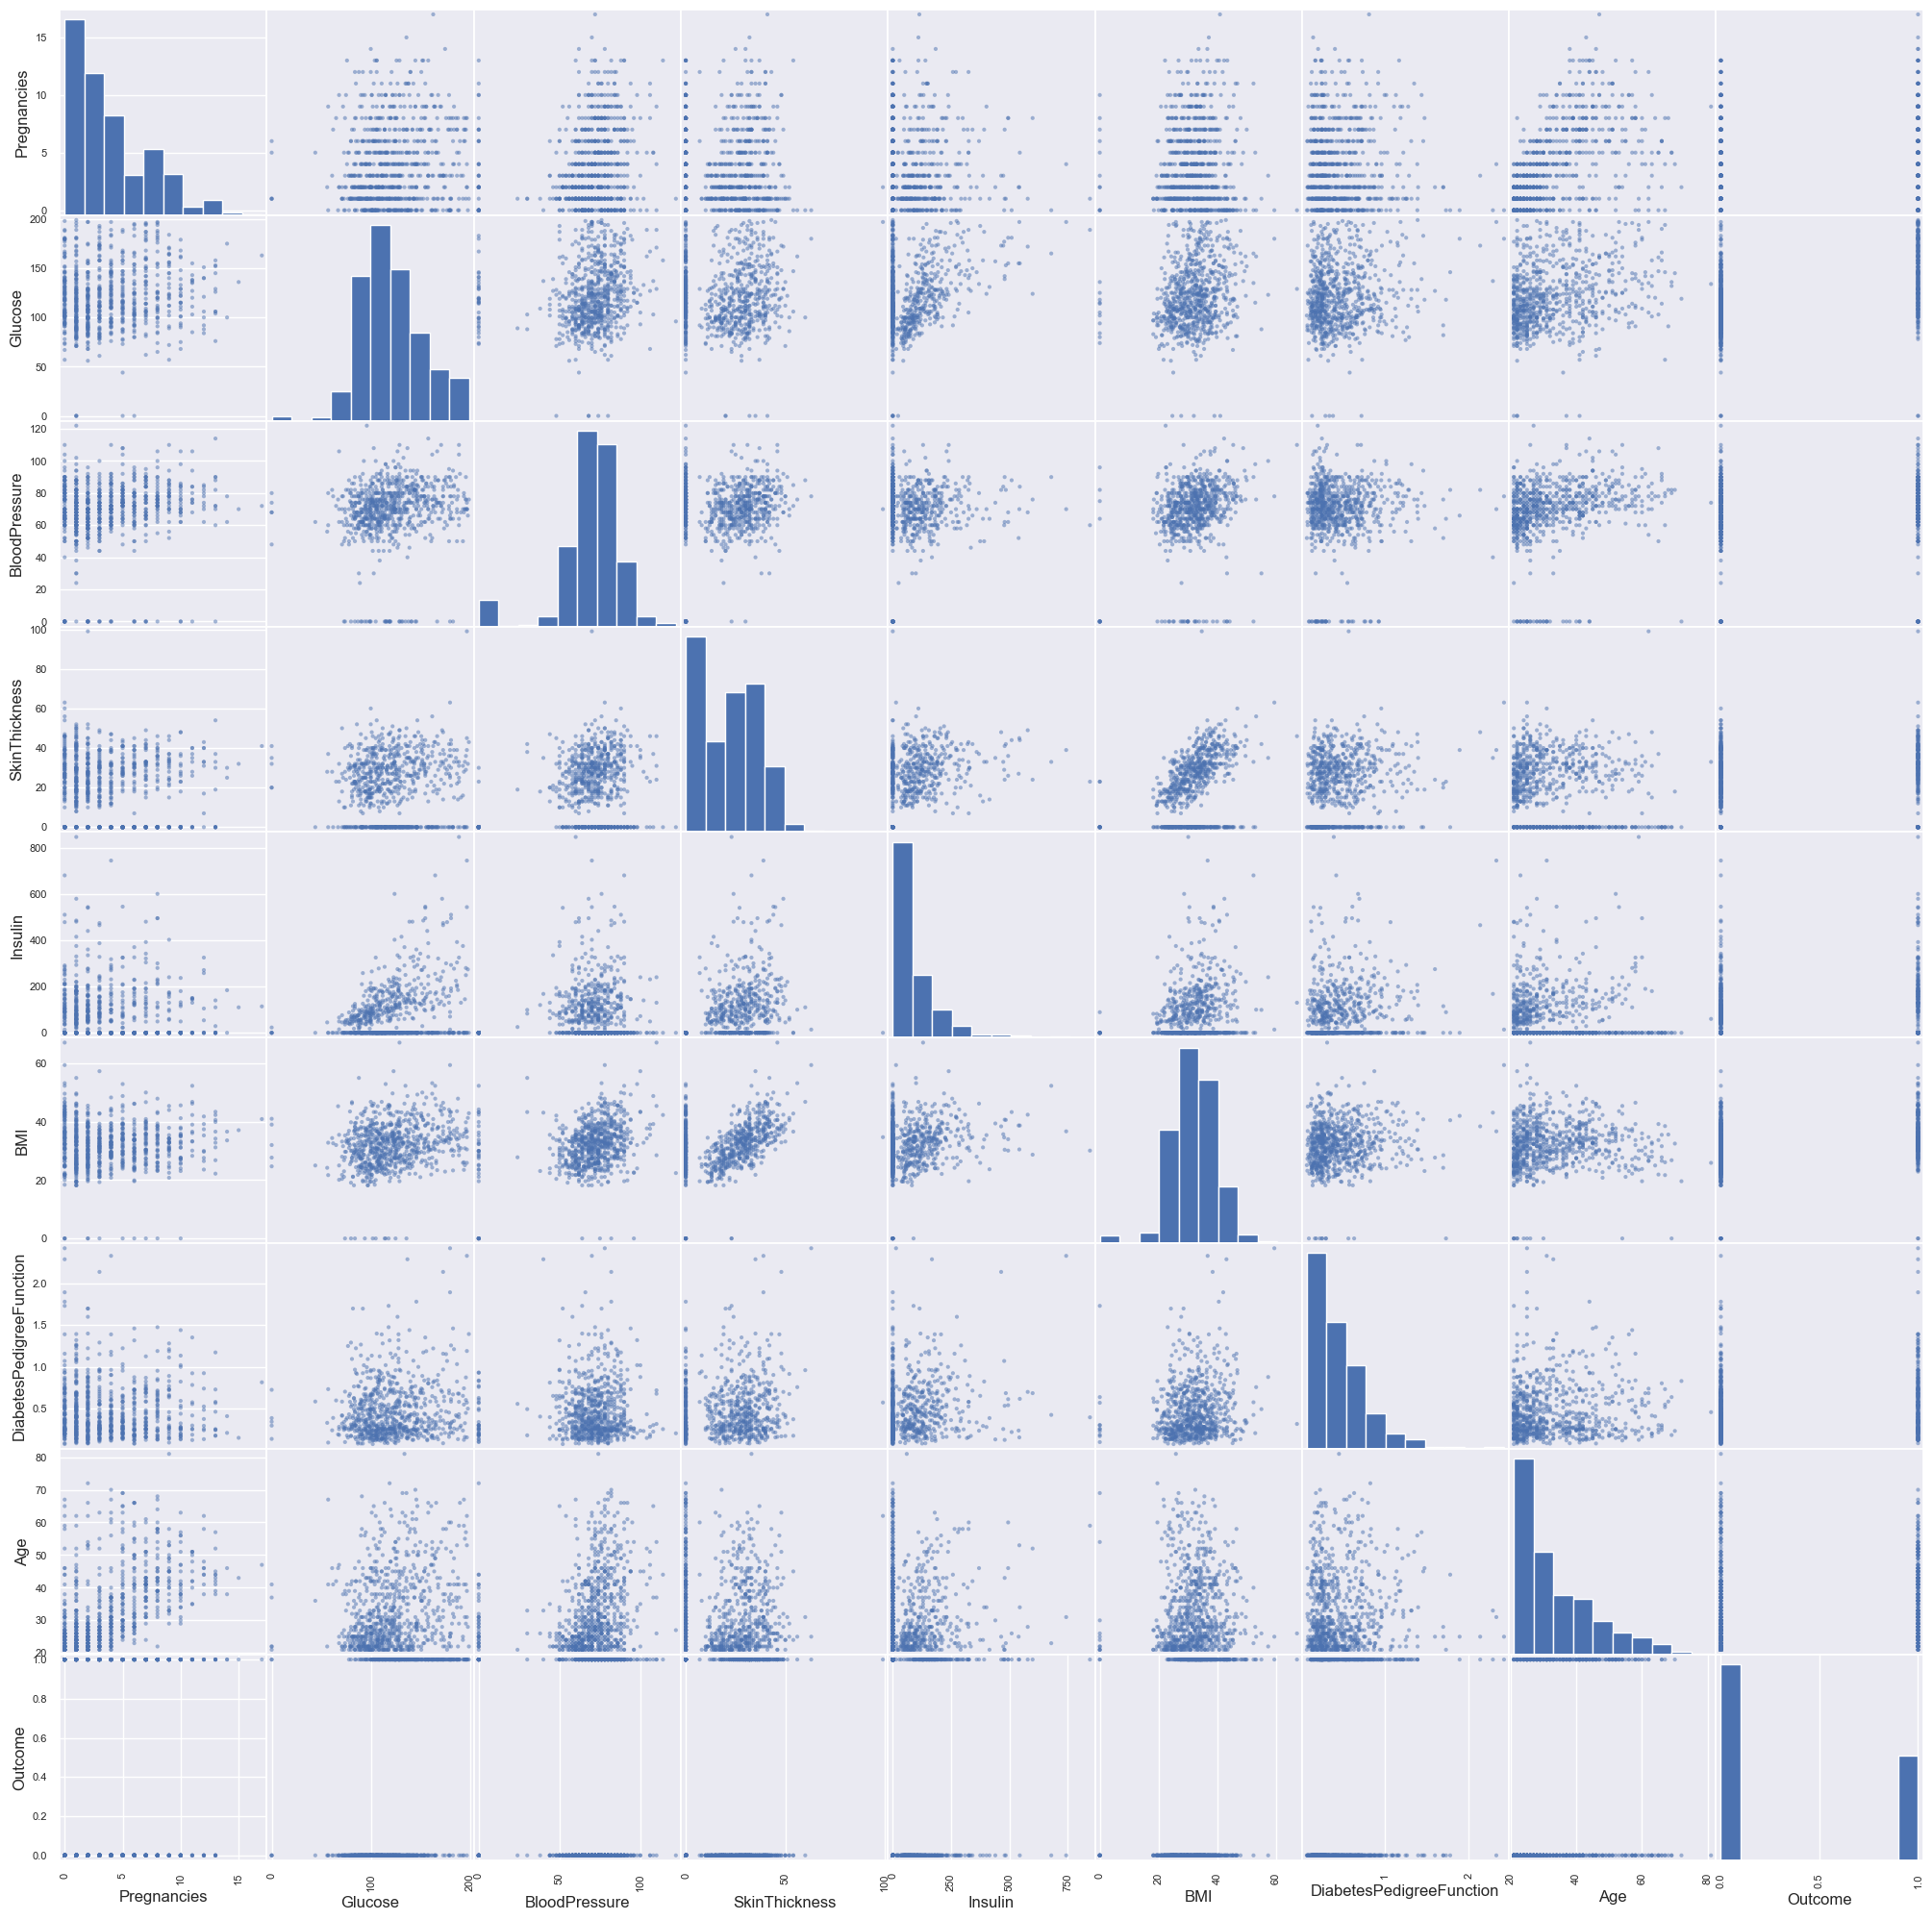

In [95]:
from pandas.plotting import scatter_matrix
p = scatter_matrix(df, figsize=(25,25)) 

It created a matrix of scatter plots for every pair of numerical columns and each plot shows how two variables are related. There's also histograms from top-left to bottom-right.

We are now going to pair plot for the clean data!

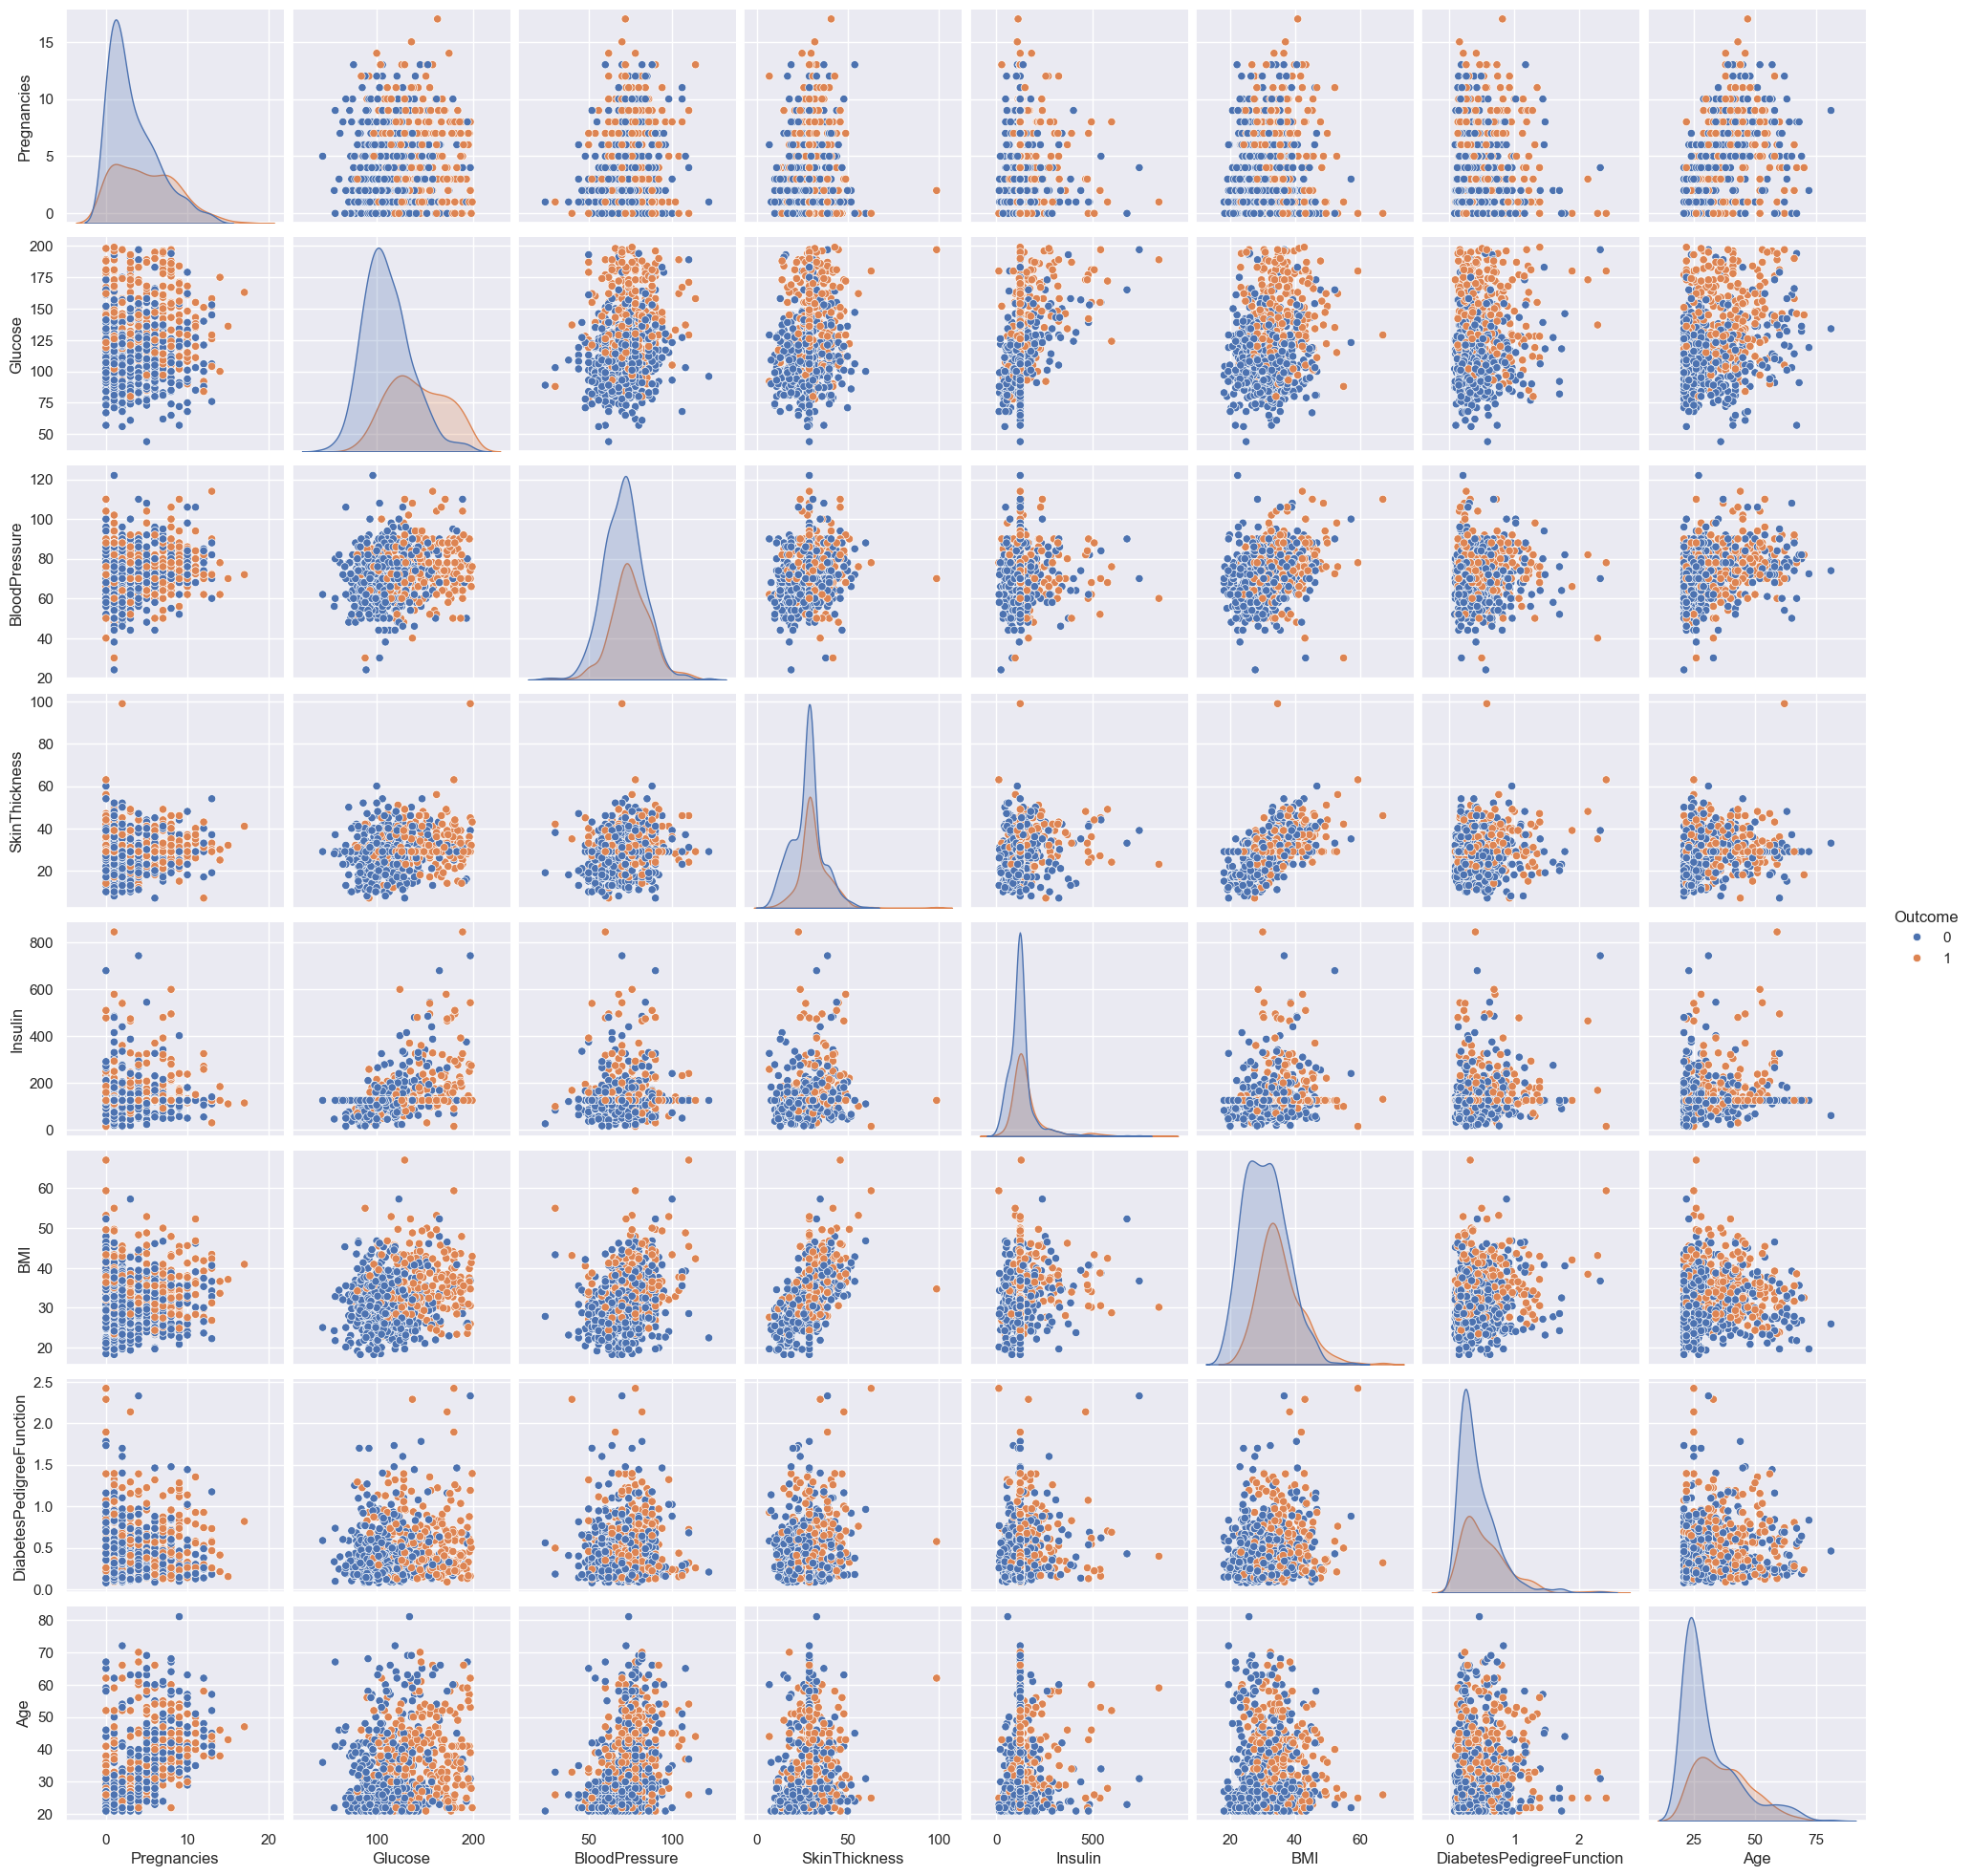

In [96]:
p = sns.pairplot(df_copy, hue='Outcome') #Different colors will represent diabetic (1) vs non-diabetic (0) indviduals

In order to observe the correlation between each column, let's use the Pearson's Correlation Coefficient. A heat map is a two-dimensional representation of information with the help of colors. Heat maps can help the user visualize complex information.

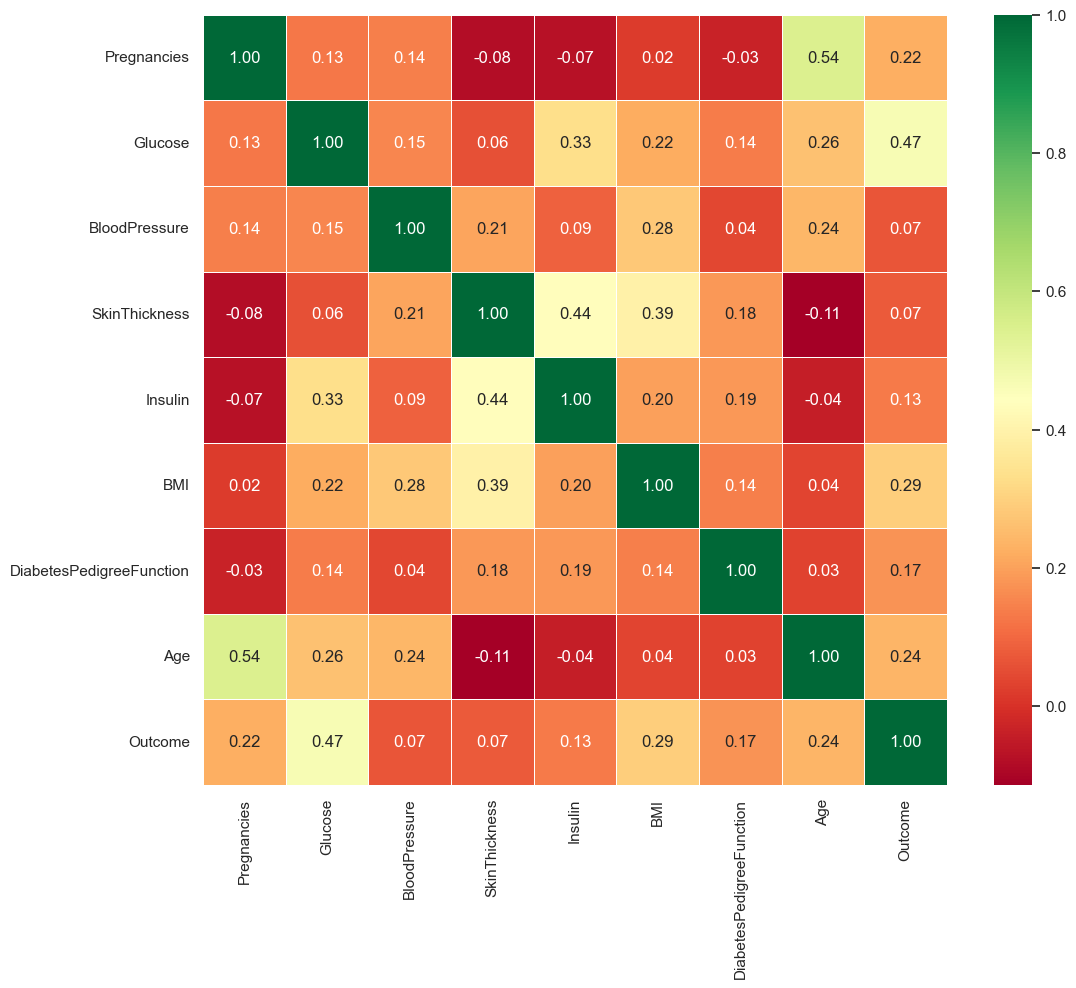

In [97]:
plt.figure(figsize=(12,10))
p= sns.heatmap(df.corr(), annot=True, cmap='RdYlGn', fmt=".2f",linewidths=0.5)

Correlation r = covariance(X,Y)/ (std(X) x std(Y))  

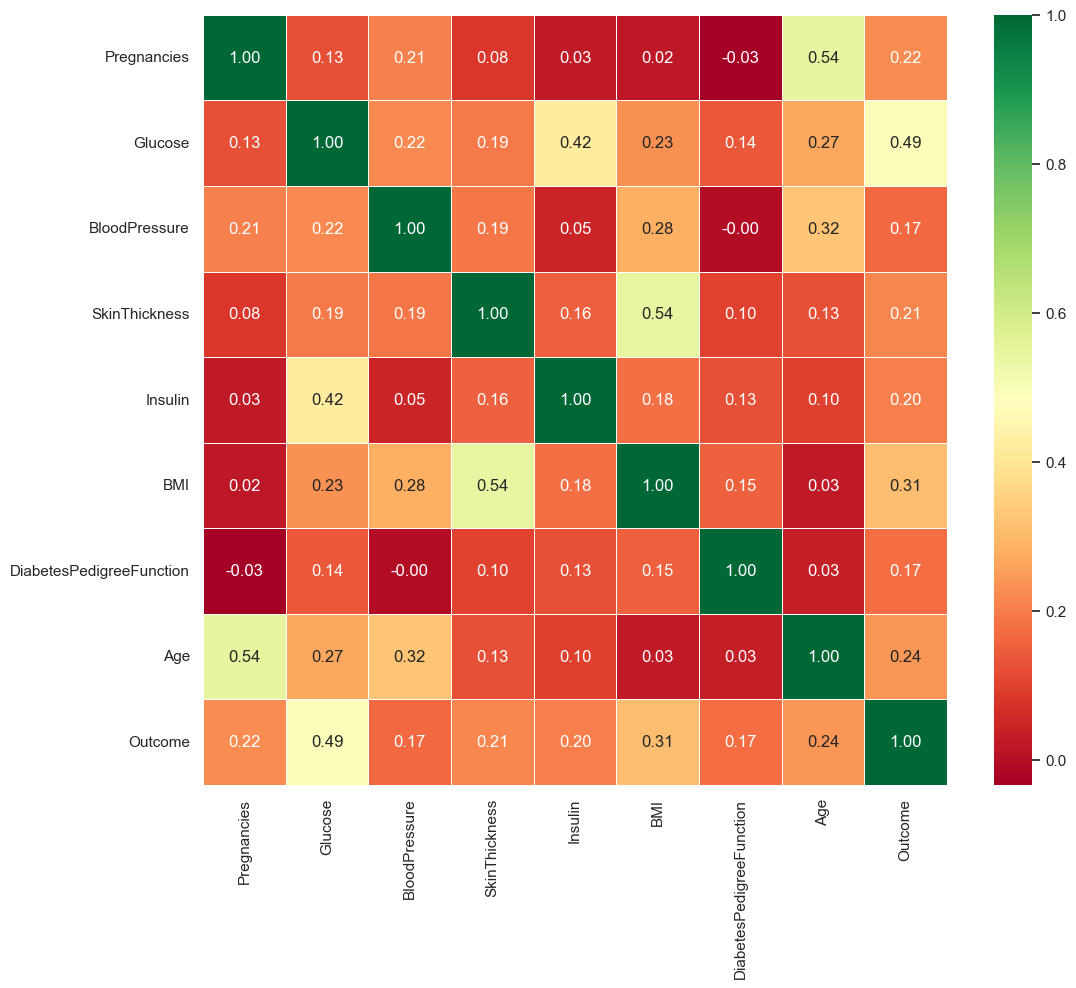

In [98]:
plt.figure(figsize=(12,10))
p= sns.heatmap(df_copy.corr(), annot=True, cmap='RdYlGn', fmt=".2f",linewidths=0.5)

### Why Scaling the data for distance based algorithms like Linear Regression etc?
It is always advisable to bring all the features to the same scale for applying distance based algorithms.

We can imagine how the feature with greater range with overshadow or dimenish the smaller feature completely and this will impact the performance of all distance based model as it will give higher weightage to variables which have higher magnitude.  

The new mean is 0 and the standard deviation is 1.

In [99]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X = pd.DataFrame(sc_X.fit_transform(df_copy.drop(['Outcome'], axis = 1),),columns=['Pregnancies', 'Glucose', 'BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age'])
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.865108,-0.033518,0.670643,-0.181541,0.166292,0.468492,1.425995
1,-0.844885,-1.206162,-0.529859,-0.012301,-0.181541,-0.852531,-0.365061,-0.190672
2,1.233880,2.015813,-0.695306,-0.012301,-0.181541,-1.332833,0.604397,-0.105584
3,-0.844885,-1.074652,-0.529859,-0.695245,-0.540642,-0.634212,-0.920763,-1.041549
4,-1.141852,0.503458,-2.680669,0.670643,0.316566,1.548980,5.484909,-0.020496


## Modeling our data 

In [100]:
y = df_copy.Outcome

In [101]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=1/3, random_state=42, stratify=y)

In [102]:
from sklearn.neighbors import KNeighborsClassifier

test_score = []
train_score = []

for i in range(1,15):
    knn = KNeighborsClassifier(i)
    knn.fit(X_train, y_train)

    train_score.append(knn.score(X_train, y_train))
    test_score.append(knn.score(X_test,y_test))

In [103]:
max_train_score = max(train_score)
train_score_ind = [i for i, v in enumerate(train_score) if v==max_train_score]
print('Max train score: {} % and k = {}'.format(max_train_score*100, list(map(lambda x: x+1, train_score_ind))))

Max train score: 100.0 % and k = [1]


In [104]:
max_test_score = max(test_score)
test_score_ind = [i for i, v in enumerate(test_score) if v==max_test_score]
print('Max test score: {} % and k = {}'.format(max_test_score*100, list(map(lambda x: x+1, test_score_ind))))

Max test score: 76.5625 % and k = [11]


<Axes: >

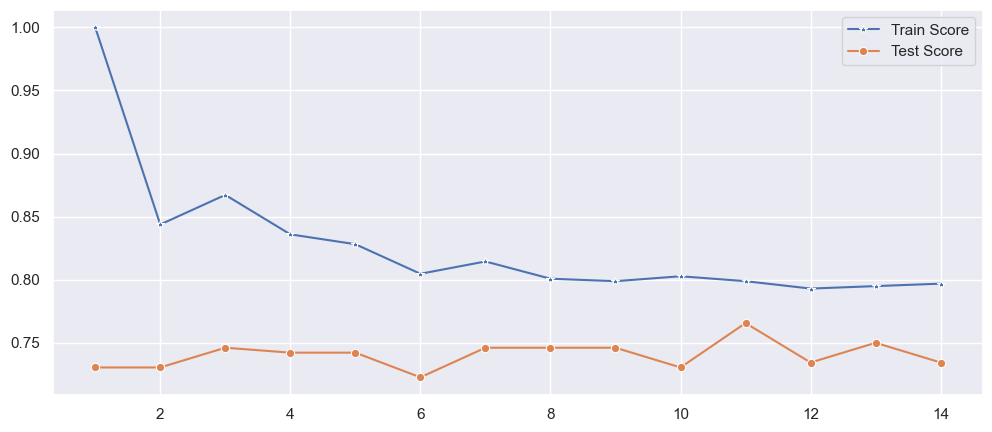

In [105]:
plt.figure(figsize=(12,5))
sns.lineplot(x=range(1,15), y=train_score, marker = '*', label='Train Score')
sns.lineplot(x=range(1,15), y=test_score, marker='o',label='Test Score')

## Interpreting our data

The best result is captured at k = 11. Therefore, 11 is used for the final model.

In [106]:
#Setup a knn classifier with k neighbors
knn = KNeighborsClassifier(11)
knn.fit(X_train,y_train)
score_1 = knn.score(X_test,y_test)
from sklearn.model_selection import cross_val_score

score_2 = cross_val_score(knn, X_train, y_train, cv=10) #cv = 10 means that we will split the data into 10 parts and train on 9 of them and test on the last one for 10 times
print('Test score: {} %'.format(score_1*100))
print('Cross validation score: {} %'.format(score_2.mean()*100))


Test score: 76.5625 %
Cross validation score: 76.7609351432881 %


We can see that the two scores are pretty similar (using cross validation or no)!  
So the accuracy of our model is roughly 77%! 


![](https://cdn-images-1.medium.com/max/1600/0*9r99oJ2PTRi4gYF_.jpg)

For Reference: https://medium.com/@djocz/confusion-matrix-aint-that-confusing-d29e18403327

In [107]:
from sklearn.metrics import confusion_matrix

y_pred = knn.predict(X_test)
confusion_matrix(y_test, y_pred)
pd.crosstab(y_test, y_pred, rownames=['True'], colnames=['Predicted'], margins=True)

Predicted,0,1,All
True,,,
0,142,25,167
1,35,54,89
All,177,79,256


True negative (0,0) = 142  

True positive (1,1) = 54  

False positive (0,1) = 25  

False negative (1,0) = 35
